# Exploration and Evaluation

This notebook uses the final project dataset to inspect label distributions and regenerate confusion matrices for sentiment and issue classification.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_PATH = ROOT / "data" / "processed" / "shopee_reviews_labeled.csv"
REPORTS_DIR = ROOT / "reports"

pd.set_option("display.max_colwidth", 120)
print("Project root:", ROOT)
print("Data path:", DATA_PATH)

Project root: C:\Users\Admin\Documents\GitHub\AIMiniProject
Data path: C:\Users\Admin\Documents\GitHub\AIMiniProject\data\processed\shopee_reviews_labeled.csv


## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)
required_columns = {"review_text", "cleaned_review", "sentiment", "issue"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

print("Shape:", df.shape)
df.head()

Shape: (6508, 6)


,page,review_text,cleaned_review,sentiment,issue,data_source
0,1,"Quần rất đẹp , vải gió thoáng mát mặc mùa này là chuẩn bài rồi. Hình in đẹp, in chắc chắn giặt máy kh lo bong luôn. ...",quần rất đẹp vải gió thoáng mát mặc mùa này là chuẩn bài rồi hình in đẹp in chắc chắn giặt máy khong lo bong luôn mì...,positive,no_issue,base_guideline_v4
1,1,Màu sắc: Đẹp Đúng với mô tả: đúng với hình ảnh Chất liệu: tốt Hàng đẹp bận mác mẻ chỉ may đẹp mọi người nên mua nha ...,màu sắc đẹp đúng với mô tả đúng với hình ảnh chất liệu tốt hàng đẹp bận mác mẻ chỉ may đẹp moi nguoi nên mua nha ưng...,positive,no_issue,base_guideline_v4
2,1,Chất lượng sản phẩm tuyệt vời. Đóng gói sản phẩm rất đẹp và chắc chắn. Shop phục vụ rất tốt. Rất đáng tiền. Thời gia...,chất lượng san pham tuyệt vời đóng gói san pham rất đẹp và chắc chắn shop phục vụ rất tốt rất đáng tiền thời gian gi...,positive,no_issue,base_guideline_v4
3,1,"Đúng với mô tả: đúng 3XL Màu sắc: đen+xanh than Chất liệu: vải dù co giản Mới nhận được hàng 2 cái quần đùi rất đẹp,...",đúng với mô tả đúng 3xl màu sắc đen xanh than chất liệu vải dù co giản mới nhận duoc hàng 2 cái quần đùi rất đẹp vải...,positive,no_issue,base_guideline_v4
4,1,"Màu sắc: đen Vải thoáng mát, đường may chắc chắn. Đã mua ủng hộ 2 lần, shop làm ăn uy tín, giao thiếu là giao bổ sun...",màu sắc đen vải thoáng mát đường may chắc chắn đã mua ủng hộ 2 lần shop làm ăn uy tín giao thiếu là giao bổ sung liề...,positive,wrong_missing_item,base_guideline_v4


In [3]:
df.isna().sum().sort_values(ascending=False)

page              0
review_text       0
cleaned_review    0
sentiment         0
issue             0
data_source       0
dtype: int64

## 2. Label distribution

In [4]:
sentiment_counts = df["sentiment"].value_counts()
issue_counts = df["issue"].value_counts()

print("Sentiment distribution:")
print(sentiment_counts.to_string())
print()
print("Issue distribution:")
print(issue_counts.to_string())

Sentiment distribution:
sentiment
negative    3366
positive    1824
neutral     1318

Issue distribution:
issue
no_issue              2097
product_quality       2073
product_attribute      758
wrong_missing_item     483
packaging              406
seller_service         302
spam_irrelevant        146
shipping_delivery      126
price_value            117


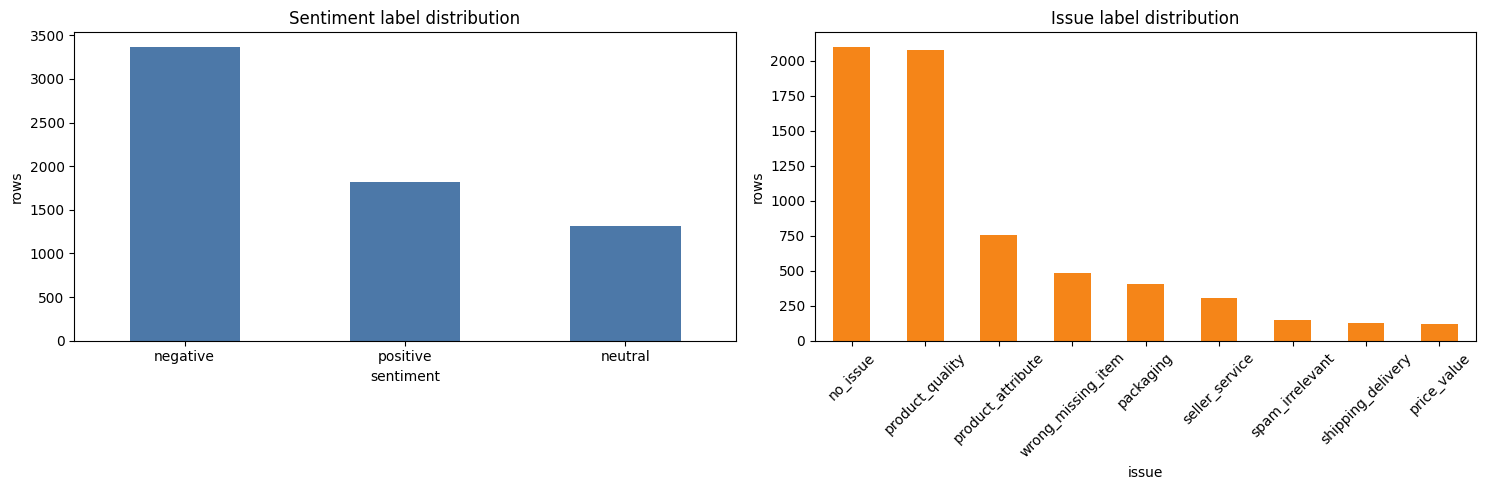

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sentiment_counts.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Sentiment label distribution")
axes[0].set_xlabel("sentiment")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=0)

issue_counts.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Issue label distribution")
axes[1].set_xlabel("issue")
axes[1].set_ylabel("rows")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

## 3. Review length and data samples

count    6508.000000
mean       74.402581
std       294.035428
min         1.000000
25%        19.000000
50%        30.000000
75%        44.250000
max      2929.000000
Name: word_count, dtype: float64

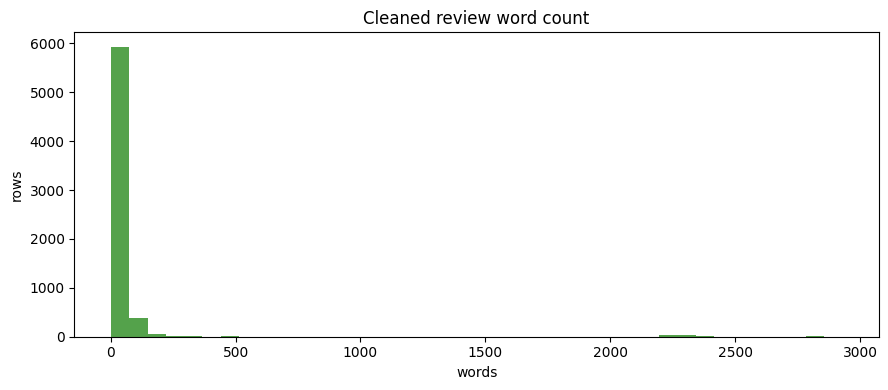

In [6]:
df["word_count"] = df["cleaned_review"].fillna("").astype(str).str.split().str.len()

ax = df["word_count"].plot(kind="hist", bins=40, figsize=(9, 4), color="#54A24B")
ax.set_title("Cleaned review word count")
ax.set_xlabel("words")
ax.set_ylabel("rows")
plt.tight_layout()

df["word_count"].describe()

In [7]:
df[["review_text", "cleaned_review", "sentiment", "issue"]].sample(10, random_state=62)

,review_text,cleaned_review,sentiment,issue
1865,"Chất liệu: ok Kích thước: vừa Bên ngoài áo màu xanh navy siêu đepj luôn ý, do ánh sáng nên trong ảnh giống màu đen t...",chất liệu ok kích thước vừa bên ngoài áo màu xanh navy siêu đepj luôn ý do ánh sáng nên trong ảnh giống màu đen thui...,positive,no_issue
5809,"Chất lượng sản phẩm: độ trễ thấp, bút nhẹ, không sạc không dây được với ipad Air M3 Sản phẩm không đúng với mô tả. T...",chất lượng san pham độ trễ thấp bút nhẹ khong sạc khong dây duoc với ipad air m3 san pham khong đúng với mô tả tôi m...,negative,seller_service
1354,"Giao hàng siêu lâu lun nha , đặt từ 7/7 tới 24/7 mới gửi hàng , ai kiên nhẫn đợi đc như mình thì đặt nha , dc cái gi...",giao hàng siêu lâu lun nha đặt từ 7 7 tới 24 7 mới gửi hàng ai kiên nhẫn đợi duoc như mình thì đặt nha duoc cái giao...,positive,shipping_delivery
2079,Chất liệu: vải co giãn Màu sắc: đúng màu,chất liệu vải co giãn màu sắc đúng màu,neutral,no_issue
1720,Deo thấy đơn đâu d.m,deo thấy đơn đâu d m,negative,shipping_delivery
5663,Shop giao thiếu quà tặng như trong mô tả. Hơi thất vọng. Không đúng như trong mô tả có 2 quà tặng 0:05 （Black Color）...,shop giao thiếu quà tặng như trong mô tả hơi thất vọng khong đúng như trong mô tả có 2 quà tặng 0 05 black color giá...,negative,wrong_missing_item
388,Giao hơi lâu gói hàng cẩn thận mà chất lượng nghe bình thường đúng giá tiền Update: tai nghe g nghe ớn lạy nghe chua...,giao hơi lâu gói hàng cẩn thận mà chất lượng nghe binh thuong đúng giá tiền update tai nghe g nghe ớn lạy nghe chua ...,neutral,product_quality
78,Chất lượng sản phẩm: tuyệt vời Đúng với mô tả: y hình Khăn đẹp lắm mn nhìn vải dày sợi lông ko bị xù nhận hàng tưởng...,chất lượng san pham tuyệt vời đúng với mô tả y hình khăn đẹp lắm moi nguoi nhìn vải dày sợi lông khong bị xù nhận hà...,positive,no_issue
1345,"Chất lượng sản phẩm: Rat tot Chất lượng sản phẩm rất tốt, sử dụng bền, cảm ơn shop!!!",chất lượng san pham rat tot chất lượng san pham rất tốt sử dụng bền cảm ơn shop,positive,no_issue
4503,Sản phẩm: Sản phẩm chất lượng kém ĐỒ GIA CÔNG KHÔNG NÊN MUA 0:09,san pham san pham chất lượng kém đồ gia công khong nên mua 0 09,negative,product_quality


## 4. Regenerate confusion matrices

This section reuses `src/evaluate.py` so the matrices in `reports/` stay aligned with the main code.

In [8]:
from evaluate import TASK_CONFIGS, evaluate_task

for task_key, config in TASK_CONFIGS.items():
    task_df = pd.read_csv(config["data_path"])
    evaluate_task(task_df, task_key, config)

Task: Sentiment Classification
Feature: TF-IDF Unigram + Bigram
Model: Linear SVM
Accuracy: 0.8318
Macro F1: 0.7993
Saved report: reports\classification_report_sentiment.txt
Saved confusion matrix: reports\confusion_matrix_sentiment.png


Task: Issue Classification
Feature: TF-IDF Word + Char
Model: Linear SVM + Safe Issue Rules
Accuracy: 0.7849
Macro F1: 0.7323
Saved report: reports\classification_report_issue.txt
Saved confusion matrix: reports\confusion_matrix_issue.png


Sentiment confusion matrix


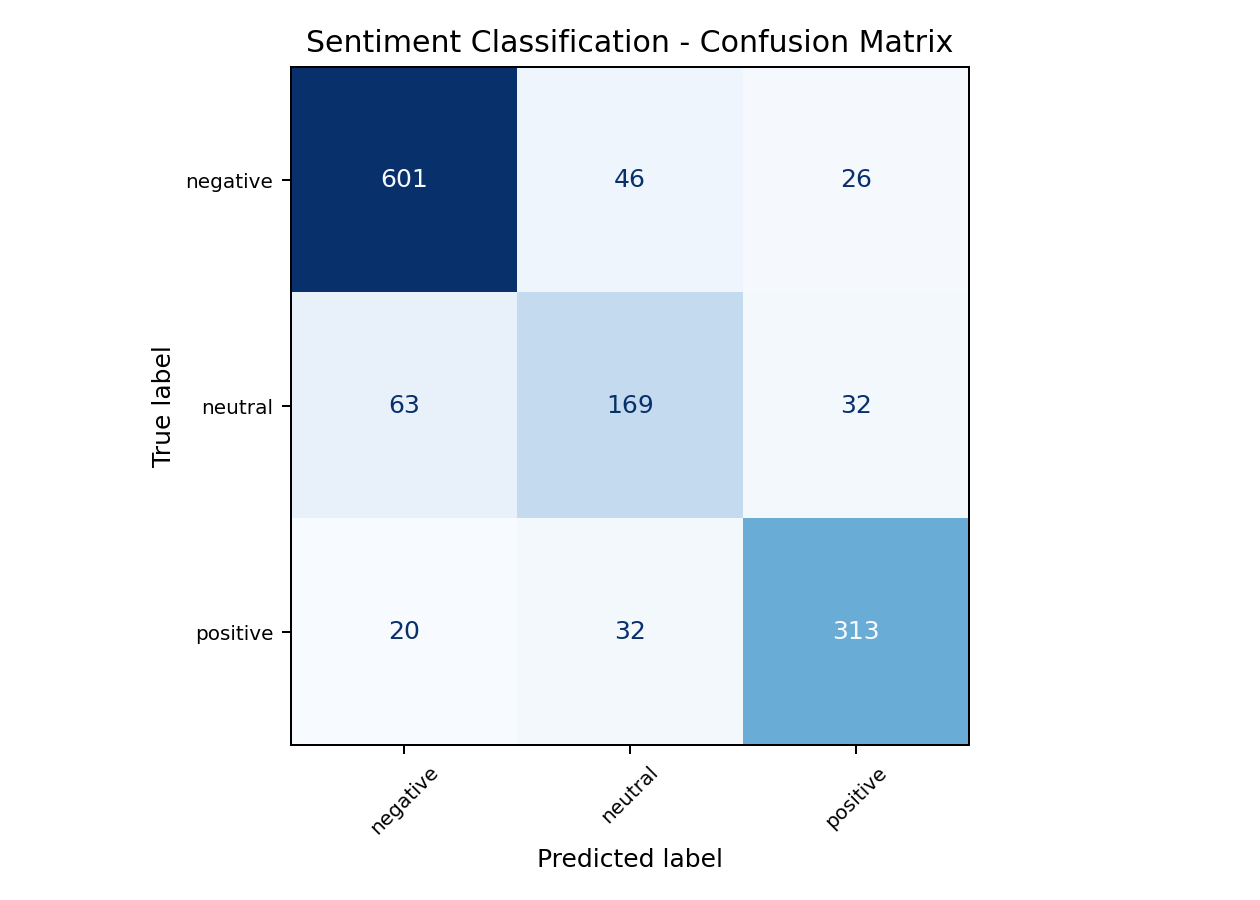

Issue confusion matrix


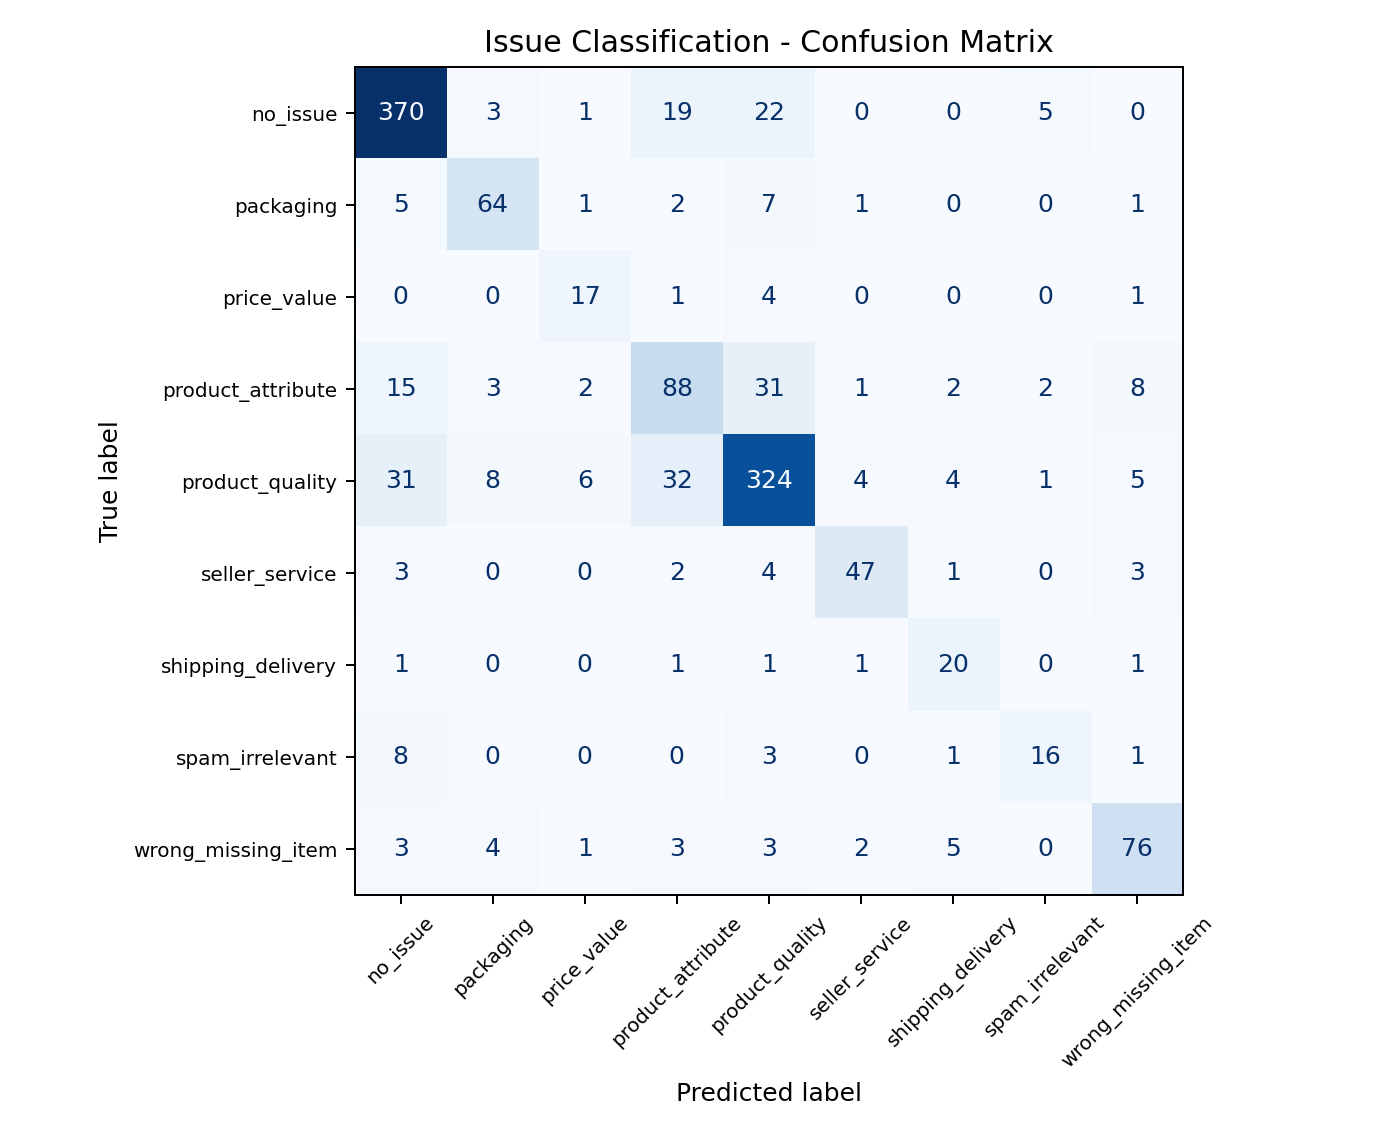

In [9]:
from IPython.display import Image, display

print("Sentiment confusion matrix")
display(Image(filename=str(REPORTS_DIR / "confusion_matrix_sentiment.png")))

print("Issue confusion matrix")
display(Image(filename=str(REPORTS_DIR / "confusion_matrix_issue.png")))

## 5. Main metrics

In [10]:
def read_metric_summary(report_path):
    lines = Path(report_path).read_text(encoding="utf-8").splitlines()
    summary = {"report": Path(report_path).name}
    for line in lines:
        if line.startswith("Task:"):
            summary["task"] = line.split(":", 1)[1].strip()
        elif line.startswith("Feature:"):
            summary["feature"] = line.split(":", 1)[1].strip()
        elif line.startswith("Model:"):
            summary["model"] = line.split(":", 1)[1].strip()
        elif line.startswith("Accuracy:"):
            summary["accuracy"] = float(line.split(":", 1)[1].strip())
        elif line.startswith("Macro F1:"):
            summary["macro_f1"] = float(line.split(":", 1)[1].strip())
    return summary

pd.DataFrame([
    read_metric_summary(REPORTS_DIR / "classification_report_sentiment.txt"),
    read_metric_summary(REPORTS_DIR / "classification_report_issue.txt"),
])

,report,task,feature,model,accuracy,macro_f1
0,classification_report_sentiment.txt,Sentiment Classification,TF-IDF Unigram + Bigram,Linear SVM,0.8318,0.7993
1,classification_report_issue.txt,Issue Classification,TF-IDF Word + Char,Linear SVM + Safe Issue Rules,0.7849,0.7323
